In [9]:
from executor import Executor, QuantumCircuit, QuantumOperator, Parameters

In [10]:
x = Parameters("x", 1)
p = Parameters("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.cry(0, 1, p[0] * x[0])

In [11]:
pop = Parameters("pop", 2)
operator = QuantumOperator(["ZI", "IZ"], [pop[0], pop[1]])

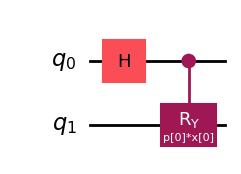

In [12]:
executor = Executor.create("qiskit", seed=0, shots=10000)

qiskit_circuit = executor.transpile_circuit(qc)
qiskit_circuit.qiskit_circuit.draw("mpl")

In [13]:
result = executor.expectation_value(
    qiskit_circuit,
    operator,
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print("Expectation value:", result)

Expectation value: 0.49677734375


In [14]:
v = executor.expectation_value_derivatives(
    qiskit_circuit,
    operator,
    "x",
    "p",
    "pop",
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print(v)

{'x': array([-0.00107666]), 'p': array([-0.00183594]), 'pop': array([[0.99951172],
       [0.01953125]])}


In [15]:
executor.statevector(
    qiskit_circuit,
    x=[0.8],
    p=[0.5],
)

array([0.70710678+0.j, 0.        +0.j, 0.69301172+0.j, 0.14048043+0.j])

In [16]:
executor.sample(
    qiskit_circuit,
    x=[0.8],
    p=[0.5],
)

{'00': 4951, '10': 4845, '11': 204}